In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
data = {
    "Outlook": [
        "Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
        "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain",
        "Sunny","Rain","Overcast","Sunny","Rain","Overcast"
    ],

    "Temp": [
        "Hot","Hot","Hot","Mild","Cool","Cool","Cool",
        "Mild","Cool","Mild","Mild","Mild","Hot","Mild",
        "Cool","Hot","Mild","Cool","Mild","Hot"
    ],

    "Humidity": [
        "High","High","High","High","Normal","Normal","Normal",
        "High","Normal","Normal","Normal","High","Normal","High",
        "Normal","High","Normal","High","Normal","High"
    ],

    "Wind": [
        "Weak","Strong","Weak","Weak","Weak","Strong","Strong",
        "Weak","Weak","Weak","Strong","Strong","Weak","Strong",
        "Weak","Strong","Weak","Strong","Weak","Strong"
    ],

    "Golf_Players": [
        25,30,46,45,52,23,43,
        35,38,46,48,52,44,30,
        39,28,47,33,49,41
    ]
}

df = pd.DataFrame(data)
df


,Outlook,Temp,Humidity,Wind,Golf_Players
0,Sunny,Hot,High,Weak,25
1,Sunny,Hot,High,Strong,30
2,Overcast,Hot,High,Weak,46
3,Rain,Mild,High,Weak,45
4,Rain,Cool,Normal,Weak,52
5,Rain,Cool,Normal,Strong,23
6,Overcast,Cool,Normal,Strong,43
7,Sunny,Mild,High,Weak,35
8,Sunny,Cool,Normal,Weak,38
9,Rain,Mild,Normal,Weak,46


In [ ]:
df_encoded = df.copy()

for col in ["Outlook","Temp","Humidity","Wind"]:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

df_encoded


,Outlook,Temp,Humidity,Wind,Golf_Players
0,2,1,0,1,25
1,2,1,0,0,30
2,0,1,0,1,46
3,1,2,0,1,45
4,1,0,1,1,52
5,1,0,1,0,23
6,0,0,1,0,43
7,2,2,0,1,35
8,2,0,1,1,38
9,1,2,1,1,46


In [ ]:
def std_dev(y):
    return np.std(y)


In [ ]:
def entropy(y):
    mean_val = np.mean(y)
    classes = y > mean_val

    p1 = np.sum(classes) / len(y)
    p0 = 1 - p1

    if p1 == 0 or p0 == 0:
        return 0

    return - (p1*np.log2(p1) + p0*np.log2(p0))


In [ ]:
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_sd = float("inf")

    for feature in X.columns:
        values = np.unique(X[feature])

        for val in values:
            left = y[X[feature] <= val]
            right = y[X[feature] > val]

            if len(left) == 0 or len(right) == 0:
                continue

            weighted_sd = (
                len(left)/len(y) * std_dev(left) +
                len(right)/len(y) * std_dev(right)
            )

            if weighted_sd < best_sd:
                best_feature = feature
                best_threshold = val
                best_sd = weighted_sd

    return best_feature, best_threshold


In [ ]:
def build_tree(X, y, depth=0, max_depth=3):

    node = {}
    node["std_dev"] = round(std_dev(y), 3)
    node["samples"] = len(y)
    mean_val = np.mean(y)

    if depth >= max_depth or std_dev(y) < 2:
        node["label"] = "Yes" if mean_val >= np.mean(df_encoded["Golf_Players"]) else "No"
        node["type"] = "leaf"
        return node

    feature, threshold = best_split(X, y)

    if feature is None:
        node["type"] = "leaf"
        return node

    node["type"] = "node"
    node["feature"] = feature
    node["threshold"] = threshold

    left_mask = X[feature] <= threshold
    right_mask = X[feature] > threshold

    node["left"] = build_tree(X[left_mask], y[left_mask], depth+1, max_depth)
    node["right"] = build_tree(X[right_mask], y[right_mask], depth+1, max_depth)

    return node


In [ ]:
X = df_encoded.drop("Golf_Players", axis=1)
y = df_encoded["Golf_Players"]

tree = build_tree(X, y)
tree


{'std_dev': 8.776,
 'samples': 20,
 'type': 'node',
 'feature': 'Outlook',
 'threshold': np.int8(0),
 'left': {'std_dev': 3.5,
  'samples': 6,
  'type': 'node',
  'feature': 'Temp',
  'threshold': np.int8(1),
  'left': {'std_dev': 1.803, 'samples': 4, 'label': 'Yes', 'type': 'leaf'},
  'right': {'std_dev': 2.5,
   'samples': 2,
   'type': 'node',
   'feature': 'Humidity',
   'threshold': np.int8(0),
   'left': {'std_dev': 0.0, 'samples': 1, 'label': 'Yes', 'type': 'leaf'},
   'right': {'std_dev': 0.0, 'samples': 1, 'label': 'Yes', 'type': 'leaf'}}},
 'right': {'std_dev': 9.174,
  'samples': 14,
  'type': 'node',
  'feature': 'Humidity',
  'threshold': np.int8(0),
  'left': {'std_dev': 5.993,
   'samples': 7,
   'type': 'node',
   'feature': 'Temp',
   'threshold': np.int8(1),
   'left': {'std_dev': 2.915, 'samples': 4, 'label': 'No', 'type': 'leaf'},
   'right': {'std_dev': 6.236, 'samples': 3, 'label': 'No', 'type': 'leaf'}},
  'right': {'std_dev': 9.156,
   'samples': 7,
   'type': '

In [ ]:
def plot_tree(node, x, y, dx, dy, ax):

    if node["type"] == "leaf":
        text = f"Leaf\nClass={node['label']}\nSD={node['std_dev']}"
        ax.text(x, y, text, ha='center',
                bbox=dict(boxstyle="round"))
        return

    text = f"{node['feature']} <= {node['threshold']}\nSD={node['std_dev']}"

    ax.text(x, y, text, ha='center',
            bbox=dict(boxstyle="round"))

    # Left branch (True)
    ax.plot([x, x-dx], [y, y-dy])
    ax.text(x-dx/2, y-dy/2, "True", ha='center')
    plot_tree(node["left"], x-dx, y-dy, dx/2, dy, ax)

    # Right branch (False)
    ax.plot([x, x+dx], [y, y-dy])
    ax.text(x+dx/2, y-dy/2, "False", ha='center')
    plot_tree(node["right"], x+dx, y-dy, dx/2, dy, ax)


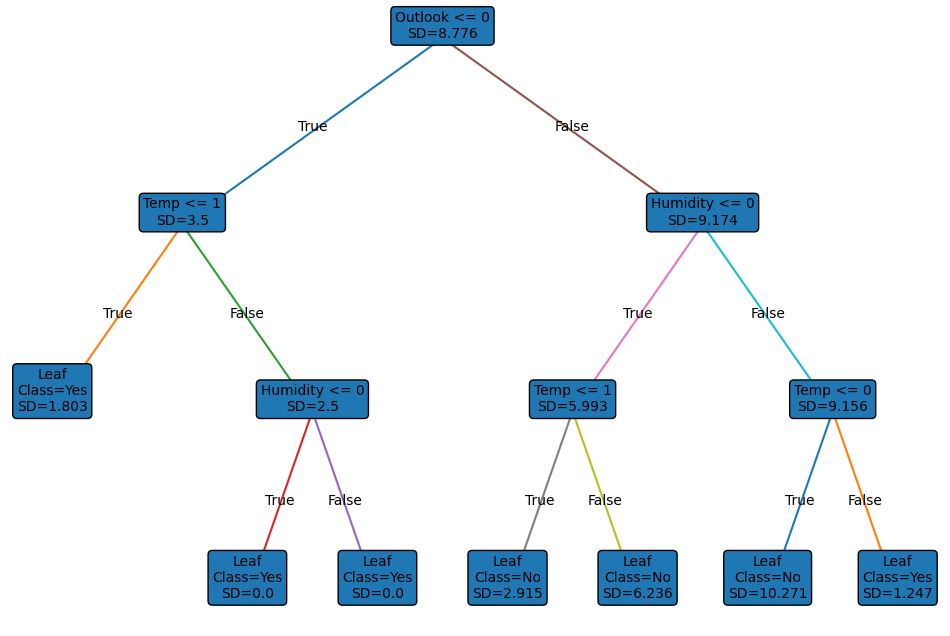

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax.set_axis_off()

plot_tree(tree, x=0.5, y=1, dx=0.25, dy=0.2, ax=ax)

plt.show()
